In [1]:
import numpy as np
import pandas as pd
import keras
from sklearn.model_selection import train_test_split
import cv2
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf

import os
import glob
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.applications import DenseNet121
from tensorflow import keras
from tensorflow.keras import models, layers
from keras.layers import Dense, Dropout, Flatten, Activation
from keras.layers import Conv1D, MaxPooling1D,MaxPooling2D
from keras.layers import Dropout
import matplotlib.pyplot as plt
import random
import os
from keras import optimizers

data=pd.read_csv('https://raw.githubusercontent.com/hinanaz231/abc/refs/heads/main/Phishing_Legitimate_full%203.csv')



In [2]:
# add random seed for reproducability??
randomseed = 69
os.environ['PYTHONHASHSEED'] = str(randomseed)
random.seed(randomseed)
np.random.seed(randomseed)
tf.random.set_seed(randomseed)
print(f"Random Seed set to {randomseed}")


Random Seed set to 69


In [3]:
# data exploration
data.columns.tolist()
data.tail()

,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
9995,9996,3,1,1,50,0,0,0,0,0,...,0,0,0,1,1,-1,1,0,1,0
9996,9997,2,1,4,59,1,0,0,0,0,...,1,0,0,1,0,0,1,0,1,0
9997,9998,2,1,4,57,0,0,0,0,0,...,0,0,0,1,0,1,1,0,1,0
9998,9999,3,1,1,49,0,0,0,0,0,...,1,0,0,1,1,0,1,0,1,0
9999,10000,3,1,2,52,3,0,0,0,0,...,0,0,0,1,1,1,1,1,1,0


In [4]:
# drop the id column
data = data.drop('id', axis=1)

# prepare test n train
y = data['CLASS_LABEL']
x = data.drop('CLASS_LABEL', axis=1)

x = x / 255.0
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=randomseed)

# Print the shapes to verify the split
print("Shape of x_train:", x_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (7000, 48)
Shape of y_train: (7000,)
Shape of x_test: (3000, 48)
Shape of y_test: (3000,)


In [5]:
#input layer
inputs= tf.keras.Input(shape=(48,))

#hidden layers
hidden_layer1 = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(inputs)
hidden_layer1 = tf.keras.layers.BatchNormalization()(hidden_layer1)
hidden_layer1 = tf.keras.layers.Dropout(0.2)(hidden_layer1)

hidden_layer2 = tf.keras.layers.Dense(128, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(1e-4))(hidden_layer1)
hidden_layer2 = tf.keras.layers.BatchNormalization()(hidden_layer2)
hidden_layer2 = tf.keras.layers.Dropout(0.2)(hidden_layer2)

hidden_layer3 = tf.keras.layers.Dense(128, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(1e-4))(hidden_layer2)
hidden_layer3 = tf.keras.layers.BatchNormalization()(hidden_layer3)
hidden_layer3 = tf.keras.layers.Dropout(0.2)(hidden_layer3)

hidden_layer4 = tf.keras.layers.Dense(256, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(1e-4))(hidden_layer3)
hidden_layer4 = tf.keras.layers.BatchNormalization()(hidden_layer4)
hidden_layer4 = tf.keras.layers.Dropout(0.2)(hidden_layer4)

#output layer
outputs = tf.keras.layers.Dense(20, activation='softmax')(hidden_layer4)

#make model
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# moved from cell below for easy access
# model compilation
model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1.5e-2),loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,188 (403.08 KB)

 Trainable params: 101,652 (397.08 KB)

 Non-trainable params: 1,536 (6.00 KB)

In [6]:
#here is the callback function , saves time in a way

from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

earlystop = EarlyStopping(monitor='val_loss', min_delta=0, patience=25,restore_best_weights=True,mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.9, patience=3)

In [7]:
history = model.fit(x_train,
          y_train,
          epochs=150,verbose=2,
          batch_size=256,
          validation_split=0.1,callbacks=[earlystop,reduce_lr],
          )


Epoch 1/150
25/25 - 12s - 466ms/step - accuracy: 0.7510 - loss: 1.1688 - val_accuracy: 0.5257 - val_loss: 0.7545 - learning_rate: 0.0150
Epoch 2/150
25/25 - 2s - 83ms/step - accuracy: 0.9106 - loss: 0.3407 - val_accuracy: 0.5129 - val_loss: 1.1582 - learning_rate: 0.0150
Epoch 3/150
25/25 - 0s - 18ms/step - accuracy: 0.9213 - loss: 0.3212 - val_accuracy: 0.5143 - val_loss: 1.1003 - learning_rate: 0.0150
Epoch 4/150
25/25 - 1s - 23ms/step - accuracy: 0.9294 - loss: 0.2922 - val_accuracy: 0.5129 - val_loss: 1.4243 - learning_rate: 0.0150
Epoch 5/150
25/25 - 0s - 18ms/step - accuracy: 0.9341 - loss: 0.2807 - val_accuracy: 0.5129 - val_loss: 1.2138 - learning_rate: 0.0135
Epoch 6/150
25/25 - 0s - 15ms/step - accuracy: 0.9387 - loss: 0.2552 - val_accuracy: 0.5129 - val_loss: 1.0674 - learning_rate: 0.0135
Epoch 7/150
25/25 - 0s - 16ms/step - accuracy: 0.9386 - loss: 0.2564 - val_accuracy: 0.5129 - val_loss: 1.5384 - learning_rate: 0.0135
Epoch 8/150
25/25 - 1s - 24ms/step - accuracy: 0.9368

In [8]:
#save the trained model
model.save('/model.keras')
print('Model saved.')

Model saved.


In [15]:
 #Load the trained model
model = keras.models.load_model('/model.keras')

# Make predictions on the test data
predictions = model.predict(x_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


Accuracy on testing dataset: 0.9766666666666667
Precision: 0.9767
Recall: 0.9767
F1 Score: 0.9767

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1505
           1       0.98      0.97      0.98      1495

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000


Model Parameters: 103,188

Inference Time (per sample): 75.2336 ± 8.3093 ms

Confusion Matrix:
[[1474   31]
 [  39 1456]]


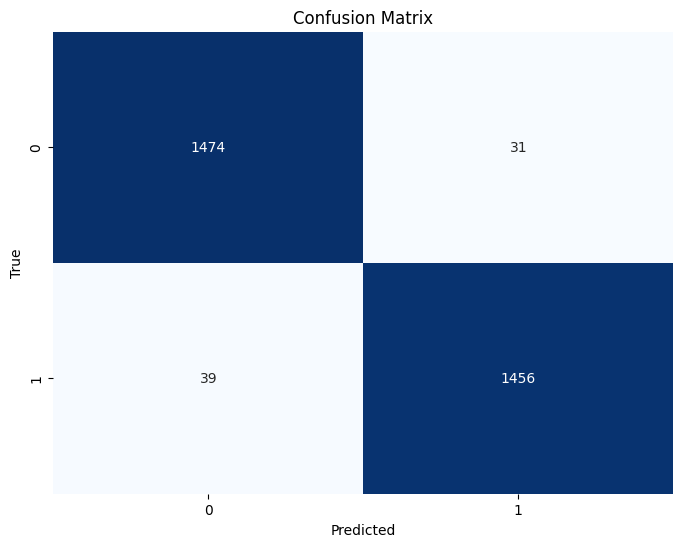


MODEL EVALUATION SUMMARY
Accuracy:        0.9767
Precision:       0.9767
Recall:          0.9767
F1 Score:        0.9767
Parameters:      103,188
Inference Time:  75.2336 ms per sample


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Calculate accuracy
# Check if predictions are probabilities (2D) or classes (1D)
if len(predictions.shape) > 1 and predictions.shape[1] > 1:
    predictions = np.argmax(predictions, axis=1)

accuracy = accuracy_score(y_test, predictions)
print('Accuracy on testing dataset:', accuracy)

# Calculate Precision, Recall, and F1 Score
precision = precision_score(y_test, predictions, average='weighted')
recall = recall_score(y_test, predictions, average='weighted')
f1 = f1_score(y_test, predictions, average='weighted')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Detailed classification report
print('\nClassification Report:')
print(classification_report(y_test, predictions))

# Model Parameters Count
def count_parameters(model):
    """Count trainable parameters in the model"""
    if hasattr(model, 'count_params'):  # Keras/TensorFlow
        return model.count_params()
    elif hasattr(model, 'parameters'):  # PyTorch
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    else:
        print("Unable to count parameters for this model type")
        return None

params = count_parameters(model)  # Replace 'model' with your actual model variable
if params:
    print(f'\nModel Parameters: {params:,}')

# Inference Time Measurement
def measure_inference_time(model, X_test, num_runs=100):
    """Measure average inference time"""
    times = []

    for _ in range(num_runs):
        start_time = time.time()

        # For TensorFlow/Keras models
        if hasattr(model, 'predict'):
            _ = model.predict(x_test[:1], verbose=0)  # Single sample
        # For PyTorch models
        elif hasattr(model, 'forward'):
            import torch
            model.eval()
            with torch.no_grad():
                _ = model(torch.tensor(X_test[:1], dtype=torch.float32))

        end_time = time.time()
        times.append(end_time - start_time)

    avg_time = np.mean(times)
    std_time = np.std(times)

    return avg_time, std_time

# Measure inference time (adjust X_test variable name as needed)
avg_inference_time, std_inference_time = measure_inference_time(model, x_test)
print(f'\nInference Time (per sample): {avg_inference_time*1000:.4f} ± {std_inference_time*1000:.4f} ms')

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(predictions))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Summary of all metrics
print("\n" + "="*50)
print("MODEL EVALUATION SUMMARY")
print("="*50)
print(f"Accuracy:        {accuracy:.4f}")
print(f"Precision:       {precision:.4f}")
print(f"Recall:          {recall:.4f}")
print(f"F1 Score:        {f1:.4f}")
if params:
    print(f"Parameters:      {params:,}")
print(f"Inference Time:  {avg_inference_time*1000:.4f} ms per sample")
print("="*50)